# Phase 5 — HateBERT + Asymmetric Loss + CDA + Cross-Dataset Evaluation

---

## What Phase 4 Found (and Why It Motivates This)

Phase 4 produced a paradoxical result that is actually the most important finding of the project:

- **FPR gaps exploded** in both BERT models vs LR baseline (`black`: 0.75+, `muslim`: 0.41+)
- **FNR gaps improved** — BERT catches more real toxicity targeting identity groups
- **Adaptive weighting made FPR worse**, not better — upweighting identity comments taught the model that identity mention ≈ toxicity signal

The diagnosis: the model conflates **mentioning a demographic group** with **attacking one**. This is the Jigsaw dataset's own annotation bias leaking into the model. Upweighting identity comments reinforced this spurious correlation instead of breaking it.

**Phase 5 attacks this with three targeted interventions:**

| Intervention | What It Fixes |
|---|---|
| **Asymmetric Loss** | Penalises FP on clean identity comments by downweighting them in loss |
| **HateBERT backbone** | Replaces DistilBERT with a model pretrained on real hate speech — better at indirect toxicity |
| **Counterfactual Data Augmentation** | Generates identity-swapped sentence pairs to break demographic co-occurrence |
| **Cross-dataset eval on HateXplain** | Tests whether the trained model generalises — or just fits Jigsaw |

---

## Estimated Runtime on T4 GPU

| Step | Time |
|---|---|
| Setup + CDA preprocessing | ~15 min |
| HateBERT + Asymmetric Loss training | ~50 min |
| Cross-dataset evaluation | ~10 min |
| Audit + Analysis + Saving | ~5 min |
| **Total** | **~80 min** |

> ⚠️ Runtime → Change runtime type → **T4 GPU** before running.

---
## Cell 1 — Mount Drive, Install Dependencies, Verify Paths

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

BASE           = '/content/drive/MyDrive/Jigsaw_Bias_Project'
DATA_PATH      = f'{BASE}/Datasets/train.csv'
LR_MODEL_PATH  = f'{BASE}/Models/logistic_regression_model.pkl'
LR_VEC_PATH    = f'{BASE}/Models/tfidf_vectorizer.pkl'
PHASE4_VANILLA = f'{BASE}/Models/bert_vanilla'
PHASE4_ADAPTIVE= f'{BASE}/Models/bert_adaptive'
HATEBERT_OUT   = f'{BASE}/Models/hatebert_asymmetric'
RESULTS_P4     = f'{BASE}/Results/'                   # Phase 4 results — READ ONLY
RESULTS_P5     = f'{BASE}/Results/Phase5/'            # Phase 5 results

os.makedirs(HATEBERT_OUT, exist_ok=True)
os.makedirs(RESULTS_P5,   exist_ok=True)

# HateBERT: BERT-base fine-tuned on ~1.5M posts from banned Reddit hate communities
# Paper: Caselli et al. 2021 — "HateBERT: Retraining BERT for Abusive Language Detection"
# HuggingFace: GroNLP/hateBERT
HATEBERT_MODEL_NAME = 'GroNLP/hateBERT'

# HateXplain: Mathew et al. 2021 — hate speech with token-level rationale annotations
# We use it for zero-shot cross-dataset generalisation testing
HATEXPLAIN_DATASET  = 'Hate-speech-CNERG/hatexplain'

!pip install -q transformers datasets

print('Verifying required files from Phase 4...')
checks = {
    'train.csv':                DATA_PATH,
    'LR model (.pkl)':          LR_MODEL_PATH,
    'TF-IDF vectorizer (.pkl)': LR_VEC_PATH,
    'Phase 4 Vanilla BERT':     f'{PHASE4_VANILLA}/config.json',
    'Phase 4 Adaptive BERT':    f'{PHASE4_ADAPTIVE}/config.json',
    'Phase 4 audit CSV':        f'{RESULTS_P4}fairness_audit_full.csv',
}
all_ok = True
for label, path in checks.items():
    ok = os.path.exists(path)
    print(f'  {"✅" if ok else "❌  MISSING":<4} {label}')
    if not ok: all_ok = False

print()
if all_ok:
    print('✅ All Phase 4 outputs verified. Safe to proceed.')
else:
    print('❌ Missing files detected. Run Phase 4 fully before continuing.')

Mounted at /content/drive
Verifying required files from Phase 4...
  ✅    train.csv
  ✅    LR model (.pkl)
  ✅    TF-IDF vectorizer (.pkl)
  ✅    Phase 4 Vanilla BERT
  ✅    Phase 4 Adaptive BERT
  ✅    Phase 4 audit CSV

✅ All Phase 4 outputs verified. Safe to proceed.


---
## Cell 2 — Imports & Device Check

In [ ]:
import pickle
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.special import softmax
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset, load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device.type.upper()}')
if device.type == 'cpu':
    print('⚠️  No GPU — change runtime to T4 GPU before training.')
else:
    print(f'✅ {torch.cuda.get_device_name(0)}')

Device: CUDA
✅ Tesla T4


---
## Cell 3 — Load Data & Prepare Balanced Split

Identical setup to Phase 4 — same `random_state=42` throughout so the test set is the same exact samples. This is non-negotiable for a valid cross-phase comparison.

In [ ]:
print('Loading data...')
train = pd.read_csv(DATA_PATH, nrows=100000)
train['is_toxic'] = (train['target'] >= 0.5).astype(int)

IDENTITY_COLS = [
    'male', 'female', 'homosexual_gay_or_lesbian',
    'christian', 'jewish', 'muslim', 'black', 'white'
]

toxic_df    = train[train['is_toxic'] == 1]
clean_df    = train[train['is_toxic'] == 0].sample(n=len(toxic_df), random_state=42)
balanced_df = pd.concat([toxic_df, clean_df]).sample(frac=1, random_state=42).reset_index(drop=True)

X = balanced_df['comment_text']
y = balanced_df['is_toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {len(X_train)} | Test : {len(X_test)}')
print(f'Class balance in test : {y_test.mean():.2%} toxic')

Loading data...
Train : 11064 | Test : 2766
Class balance in test : 48.70% toxic


---
## Module A — Counterfactual Data Augmentation (CDA)

---

### Cell 4 — What CDA Does and Why

**The core problem CDA solves:** The model learned that *mentioning* `muslim` or `black` correlates with toxicity in the Jigsaw dataset. This correlation is real in the training data — these groups are mentioned more often in toxic comments — but it's a spurious signal. A comment mentioning 'muslim' in a neutral political discussion should not be flagged as toxic.

**How CDA works:** For every comment that mentions a specific identity term, we generate a "counterfactual twin" by substituting a different identity term from the same category. For example:

- Original: *"Muslims are a threat to our society"* → label: toxic
- Counterfactual: *"Christians are a threat to our society"* → label: toxic

Both twins get added to the training set with the same label. The model now sees that the *same sentence structure with different identity terms* carries the same toxicity label. This directly breaks the demographic co-occurrence shortcut.

**Why dictionary-based (not generative):** A generative approach (using GPT to rewrite sentences) would introduce paraphrase noise and is slow on T4. Dictionary substitution preserves sentence structure exactly, which is what we need — we want the model to see minimal pairs that differ only in the identity term.

**Substitution groups** (within-group swaps only — we never swap across categories like religion→gender):
- Religion: muslim ↔ christian ↔ jewish
- Gender: male ↔ female
- Race: black ↔ white

In [ ]:
# ── CDA Substitution Dictionary ──────────────────────────────────────────────
# Each group contains term variants (singular, plural, adjective forms).
# For each comment, we generate one counterfactual per applicable substitution group.
# We do NOT cross-substitute across categories (religion → race etc.)

CDA_GROUPS = [
    # Religion group — all terms are interchangeable within the group
    {
        'muslim':    ['muslim', 'muslims', 'islamic', 'islam', 'islamist', 'islamists'],
        'christian': ['christian', 'christians', 'christianity', 'catholic', 'catholics'],
        'jewish':    ['jewish', 'jews', 'jew', 'judaism', 'hebrew']
    },
    # Gender group
    {
        'male':   ['man', 'men', 'male', 'males', 'boy', 'boys', 'guy', 'guys', 'he', 'his', 'him'],
        'female': ['woman', 'women', 'female', 'females', 'girl', 'girls', 'she', 'her', 'hers']
    },
    # Race group
    {
        'black': ['black', 'blacks', 'african american', 'african-american'],
        'white': ['white', 'whites', 'caucasian', 'caucasians']
    }
]

import re

def generate_counterfactuals(text, label):
    """
    For a given text, generate counterfactual versions by swapping identity terms.
    Returns a list of (augmented_text, label) tuples.
    Only generates counterfactuals if the original text contains a known identity term.
    One swap per substitution group per comment — avoids combinatorial explosion.
    """
    augmented = []
    text_lower = text.lower()

    for group in CDA_GROUPS:
        identities = list(group.keys())

        # Find which identity in this group appears in the text
        found_identity = None
        for identity in identities:
            for term in group[identity]:
                # Word boundary match — avoid 'he' matching 'the'
                if re.search(r'\b' + re.escape(term) + r'\b', text_lower):
                    found_identity = identity
                    break
            if found_identity:
                break

        if not found_identity:
            continue  # no identity term from this group found

        # Generate one counterfactual for each OTHER identity in the group
        for target_identity in identities:
            if target_identity == found_identity:
                continue
            new_text = text
            # Swap each term from source identity to first term of target identity
            target_term = group[target_identity][0]  # use canonical form
            for source_term in group[found_identity]:
                pattern = re.compile(r'\b' + re.escape(source_term) + r'\b', re.IGNORECASE)
                new_text = pattern.sub(target_term, new_text)
            if new_text != text:  # only add if something actually changed
                augmented.append((new_text, label))
                break  # one counterfactual per group per comment is enough

    return augmented


# ── Apply CDA to training set ─────────────────────────────────────────────────
# Only augment training data — NEVER the test set (would contaminate evaluation)
print('Generating counterfactual training samples...')
print('(This runs on CPU — expect ~3-5 minutes for 80k samples)')

train_texts  = X_train.values.tolist()
train_labels = y_train.values.tolist()

cda_texts  = []
cda_labels = []
cda_count  = 0

for text, label in zip(train_texts, train_labels):
    pairs = generate_counterfactuals(str(text), label)
    for aug_text, aug_label in pairs:
        cda_texts.append(aug_text)
        cda_labels.append(aug_label)
        cda_count += 1

# Combine original + augmented training data
all_train_texts  = train_texts  + cda_texts
all_train_labels = train_labels + cda_labels

print(f'\nOriginal training samples : {len(train_texts):,}')
print(f'CDA augmented samples     : {cda_count:,}')
print(f'Total training samples    : {len(all_train_texts):,}')
print(f'Augmentation ratio        : {len(all_train_texts)/len(train_texts):.2f}×')

Generating counterfactual training samples...
(This runs on CPU — expect ~3-5 minutes for 80k samples)

Original training samples : 11,064
CDA augmented samples     : 3,827
Total training samples    : 14,891
Augmentation ratio        : 1.35×


---
## Module B — Asymmetric Loss Weights

---

### Cell 5 — Computing Asymmetric Weights

**What went wrong in Phase 4:** Adaptive weighting upweighted all identity-mentioning comments regardless of their label. Clean identity comments got 3-5× weight, which made the model hypersensitive to identity terms in *any* context.

**The fix — separate treatment by label:**

| Comment type | Weight | Reasoning |
|---|---|---|
| Toxic + identity mention | 3.0× | Model must detect this — it's the actual harm |
| **Clean + identity mention** | **0.4×** | Model must NOT flag this — downweight to fight FPR |
| All other comments | 1.0× | Standard weight |

This is the key insight: the FPR problem requires *negative reinforcement* for false alarm patterns. Downweighting clean identity comments in the loss tells the gradient: "getting these wrong in the positive direction is heavily penalised." The 0.4× is not arbitrary — it's chosen to roughly balance the 3.0× upweight so the net gradient signal on identity comments is centred.

In [ ]:
# ── Asymmetric weight assignment ──────────────────────────────────────────────
# Applied to the CDA-augmented training set.
# Note: CDA samples inherit the same label as their source — so a toxic comment's
# counterfactual twin also gets 3.0× weight.

WEIGHT_TOXIC_IDENTITY = 3.0   # upweight: catch real hate targeting identity groups
WEIGHT_CLEAN_IDENTITY = 0.4   # downweight: stop over-flagging identity mentions
WEIGHT_DEFAULT        = 1.0

# For the augmented training set, we need to know which samples mention identities.
# We do a simple term-scan rather than re-using identity columns (which only exist
# in balanced_df, not in the CDA-generated samples).

all_identity_terms = set()
for group in CDA_GROUPS:
    for terms in group.values():
        all_identity_terms.update(terms)

def mentions_identity(text):
    text_lower = str(text).lower()
    return any(re.search(r'\b' + re.escape(t) + r'\b', text_lower)
               for t in all_identity_terms)

print('Computing asymmetric weights for augmented training set...')
all_train_weights = []
for text, label in zip(all_train_texts, all_train_labels):
    if mentions_identity(text):
        w = WEIGHT_TOXIC_IDENTITY if label == 1 else WEIGHT_CLEAN_IDENTITY
    else:
        w = WEIGHT_DEFAULT
    all_train_weights.append(w)

# Test set weights — 1.0 for all (weights only affect training, not evaluation)
test_weights = [1.0] * len(X_test)

weight_series = pd.Series(all_train_weights)
print(f'\nWeight distribution in augmented training set:')
print(weight_series.value_counts().sort_index().to_string())
print(f'\nMean weight : {weight_series.mean():.3f}')
print(f'Toxic identity samples (3.0×) : {(weight_series == 3.0).sum():,}')
print(f'Clean identity samples (0.4×) : {(weight_series == 0.4).sum():,}')
print(f'Neutral samples (1.0×)        : {(weight_series == 1.0).sum():,}')

Computing asymmetric weights for augmented training set...

Weight distribution in augmented training set:
0.4    2759
1.0    7628
3.0    4504

Mean weight : 1.494
Toxic identity samples (3.0×) : 4,504
Clean identity samples (0.4×) : 2,759
Neutral samples (1.0×)        : 7,628


---
## Module C — HateBERT Training

---

### Cell 6 — Tokenisation with HateBERT

**Why HateBERT over DistilBERT:** DistilBERT was pretrained on Wikipedia and BooksCorpus — clean, formal text. It has never seen the linguistic patterns of actual hate speech: coded language, dog whistles, reclaimed slurs used non-toxically, or the structural indirectness of comment-section hostility.

HateBERT (Caselli et al., 2021) was trained on ~1.5 million posts from Reddit communities that were banned for hate speech. It understands the register of online toxicity in a way general BERT cannot. This directly targets the false negative problem — comments the model missed in Phase 4 (confidence 0.02–0.15 on genuinely toxic content) are exactly the kind of indirect, low-signal toxicity that HateBERT was pretrained to recognise.

HateBERT uses the same BERT-base architecture as DistilBERT (just not distilled), so `AutoTokenizer` and `AutoModelForSequenceClassification` handle it transparently — no code changes beyond the model name.

In [ ]:
print(f'Loading HateBERT tokenizer from {HATEBERT_MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(HATEBERT_MODEL_NAME)

def make_hf_dataset(texts, labels, weights):
    """Package into HuggingFace Dataset and tokenize.
    Accepts plain lists — works for both original and CDA-augmented data."""
    df = pd.DataFrame({
        'text':    [str(t) for t in texts],
        'labels':  labels,
        'weights': weights
    }).reset_index(drop=True)
    hf = Dataset.from_pandas(df)
    return hf.map(
        lambda ex: tokenizer(
            ex['text'],
            padding='max_length',
            truncation=True,
            max_length=128
        ),
        batched=True
    )

print('Tokenizing augmented training set (CDA + original)...')
print('(Larger than Phase 4 due to CDA — expect ~4-6 mins)')
tokenized_train = make_hf_dataset(
    all_train_texts, all_train_labels, all_train_weights
)

print('Tokenizing test set...')
tokenized_test = make_hf_dataset(
    X_test.values.tolist(), y_test.values.tolist(), test_weights
)

print(f'\n✅ Tokenization complete.')
print(f'   Train samples : {len(tokenized_train):,}')
print(f'   Test samples  : {len(tokenized_test):,}')

Loading HateBERT tokenizer from GroNLP/hateBERT...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizing augmented training set (CDA + original)...
(Larger than Phase 4 due to CDA — expect ~4-6 mins)


Map:   0%|          | 0/14891 [00:00<?, ? examples/s]

Tokenizing test set...


Map:   0%|          | 0/2766 [00:00<?, ? examples/s]


✅ Tokenization complete.
   Train samples : 14,891
   Test samples  : 2,766


---
### Cell 7 — Asymmetric Trainer Definition

Same `WeightedTrainer` pattern from Phase 4. The asymmetric weights are already baked into the dataset — the trainer just applies them. The only new hyperparameter reasoning here is `num_train_epochs=3` instead of 2: HateBERT starts from a domain-adapted checkpoint (hate speech Reddit) rather than general Wikipedia, so it converges on the Jigsaw task faster. Three epochs gives it enough signal without overfitting.

In [ ]:
class AsymmetricTrainer(Trainer):
    """
    Applies per-sample asymmetric loss weights to HateBERT fine-tuning.
    Clean identity comments (weight=0.4) contribute less to the gradient
    than toxic identity comments (weight=3.0), directly targeting FPR reduction.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        weights = inputs.pop('weights', None)

        outputs = model(**inputs)
        logits  = outputs.get('logits')

        loss_fct = nn.CrossEntropyLoss(reduction='none')
        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )
        loss = (loss * weights).mean() if weights is not None else loss.mean()
        return (loss, outputs) if return_outputs else loss


def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': p, 'recall': r}


training_args = TrainingArguments(
    output_dir=HATEBERT_OUT,
    num_train_epochs=3,               # 3 epochs: HateBERT converges faster from domain-adapted start
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,               # standard BERT fine-tuning LR
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=True,
    remove_unused_columns=False,      # keeps 'weights' column alive
    report_to='none'
)

print('✅ AsymmetricTrainer and TrainingArguments defined.')

✅ AsymmetricTrainer and TrainingArguments defined.


---
### Cell 8 — Train HateBERT with Asymmetric Loss + CDA (~50 mins)

> ⏱️ This is the main training cell. ~50 minutes on T4. The progress bar shows per-step loss. Watch the eval F1 at each epoch — if it's not improving epoch-over-epoch, training can be stopped early.

In [ ]:
print('=' * 65)
print('TRAINING HateBERT + Asymmetric Loss + CDA Augmentation')
print('=' * 65)
print(f'Backbone        : {HATEBERT_MODEL_NAME}')
print(f'Training samples: {len(tokenized_train):,} (original + CDA)')
print(f'Toxic identity weight  : {WEIGHT_TOXIC_IDENTITY}×')
print(f'Clean identity weight  : {WEIGHT_CLEAN_IDENTITY}×')
print()

model_hatebert = AutoModelForSequenceClassification.from_pretrained(
    HATEBERT_MODEL_NAME, num_labels=2
).to(device)

trainer_hatebert = AsymmetricTrainer(
    model=model_hatebert,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

trainer_hatebert.train()

trainer_hatebert.save_model(HATEBERT_OUT)
tokenizer.save_pretrained(HATEBERT_OUT)
print(f'\n✅ HateBERT model saved to {HATEBERT_OUT}')

TRAINING HateBERT + Asymmetric Loss + CDA Augmentation
Backbone        : GroNLP/hateBERT
Training samples: 14,891 (original + CDA)
Toxic identity weight  : 3.0×
Clean identity weight  : 0.4×



model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.648896,0.389898,0.851772,0.853152,0.824221,0.884187
2,0.231644,0.501663,0.859002,0.859712,0.833915,0.887157
3,0.118773,0.624847,0.858641,0.860107,0.830110,0.892353


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ HateBERT model saved to /content/drive/MyDrive/Jigsaw_Bias_Project/Models/hatebert_asymmetric


---
### Cell 9 — Generate HateBERT Predictions on Jigsaw Test Set

In [ ]:
def get_predictions(trainer, tokenized_test):
    out   = trainer.predict(tokenized_test)
    probs = softmax(out.predictions, axis=1)
    y_prob = probs[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return y_pred, y_prob

print('Generating HateBERT predictions on Jigsaw test set...')
y_pred_hatebert, y_prob_hatebert = get_predictions(trainer_hatebert, tokenized_test)

p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_hatebert, average='binary')
acc = accuracy_score(y_test, y_pred_hatebert)
print(f'\nHateBERT Performance on Jigsaw Test Set:')
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1        : {f1:.4f}')
print(f'  Precision : {p:.4f}')
print(f'  Recall    : {r:.4f}')

Generating HateBERT predictions on Jigsaw test set...



HateBERT Performance on Jigsaw Test Set:
  Accuracy  : 0.8586
  F1        : 0.8601
  Precision : 0.8301
  Recall    : 0.8924


---
## Module D — 4-Way Fairness Audit (Adding HateBERT to Phase 4 Results)

---

### Cell 10 — Load Phase 4 Results & Run Complete Audit

We reload the Phase 4 audit results (LR, Vanilla BERT, Adaptive BERT) and add HateBERT as the fourth model. This gives a complete progression table:

`LR → Vanilla BERT → Adaptive BERT → HateBERT+CDA+Asymmetric`

Each step represents a methodological upgrade. The table shows whether each upgrade helped, hurt, or was neutral on FPR and FNR gaps per identity group.

In [ ]:
def compute_fpr_fnr(y_true, y_pred):
    if len(y_true) == 0:
        return 0.0, 0.0
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    return fpr, fnr

def classify_gap(gap):
    if gap < 0.02:            return 'Minimal'
    elif 0.02 <= gap <= 0.05: return 'Moderate'
    else:                     return 'Serious'

def run_fairness_audit(y_pred, model_name):
    y_pred_s  = pd.Series(y_pred, index=y_test.index)
    test_data = balanced_df.loc[X_test.index]
    rows = []
    for identity in IDENTITY_COLS:
        subgroup   = test_data[test_data[identity] >= 0.5]
        background = test_data[test_data[identity] <  0.5]
        if len(subgroup) < 10:
            continue
        fpr_sub,  fnr_sub  = compute_fpr_fnr(y_test.loc[subgroup.index],   y_pred_s.loc[subgroup.index])
        fpr_back, fnr_back = compute_fpr_fnr(y_test.loc[background.index], y_pred_s.loc[background.index])
        rows.append({
            'Identity':      identity,
            'Model':         model_name,
            'Subgroup_N':    len(subgroup),
            'FPR_Sub':       round(fpr_sub,  4),
            'FPR_Back':      round(fpr_back, 4),
            'FPR_Gap':       round(abs(fpr_sub - fpr_back), 4),
            'FNR_Sub':       round(fnr_sub,  4),
            'FNR_Back':      round(fnr_back, 4),
            'FNR_Gap':       round(abs(fnr_sub - fnr_back), 4),
            'FPR_Severity':  classify_gap(abs(fpr_sub - fpr_back)),
            'FNR_Severity':  classify_gap(abs(fnr_sub - fnr_back)),
        })
    return pd.DataFrame(rows)

# Load Phase 4 audit and append HateBERT
print('Loading Phase 4 audit results...')
audit_p4   = pd.read_csv(f'{RESULTS_P4}fairness_audit_full.csv')
audit_hb   = run_fairness_audit(y_pred_hatebert, 'HateBERT+CDA+Asym')

full_audit = pd.concat([audit_p4, audit_hb], ignore_index=True)
full_audit.to_csv(f'{RESULTS_P5}fairness_audit_phase5_full.csv', index=False)
print('✅ 4-way audit complete.')

Loading Phase 4 audit results...
✅ 4-way audit complete.


---
### Cell 11 — Print 4-Way Comparison Table

In [ ]:
MODEL_ORDER = ['LR Baseline', 'Vanilla BERT', 'Adaptive BERT', 'HateBERT+CDA+Asym']

print('\n' + '=' * 90)
print('  FAIRNESS AUDIT — 4-WAY PROGRESSION')
print('  LR Baseline → Vanilla BERT → Adaptive BERT → HateBERT+CDA+Asymmetric')
print('=' * 90)

for identity in IDENTITY_COLS:
    sub = full_audit[full_audit['Identity'] == identity]
    if sub.empty: continue
    n = sub.iloc[0]['Subgroup_N'] if 'Subgroup_N' in sub.columns else '?'
    print(f'\n  ── {identity.upper()} (subgroup n={n}) ──')
    print(f'  {"Model":<22} {"FPR Gap":>10} {"Sev":<10} {"FNR Gap":>10} {"Sev"}')
    print(f'  {"-"*22} {"-"*10} {"-"*10} {"-"*10} {"-"*10}')
    for model in MODEL_ORDER:
        mrow = sub[sub['Model'] == model]
        if mrow.empty: continue
        mdata = mrow.iloc[0]
        marker = ' ◀' if model == 'HateBERT+CDA+Asym' else ''
        print(f'  {model:<22} {mdata["FPR_Gap"]:>10.4f} {mdata["FPR_Severity"]:<10} '
              f'{mdata["FNR_Gap"]:>10.4f} {mdata["FNR_Severity"]}{marker}')

# Cast metrics to plain float — precision_recall_fscore_support can return
# numpy scalar arrays that break f-string format specifiers
_acc = float(acc)
_f1  = float(f1)
_p   = float(p)
_r   = float(r)
print('\n' + '=' * 90)
print('  OVERALL PERFORMANCE — JIGSAW TEST SET (balanced 50/50)')
print('=' * 90)
print(f'  {"Model":<22} {"Accuracy":>10} {"F1":>8} {"Precision":>12} {"Recall":>10}')
print(f'  {"-"*22} {"-"*10} {"-"*8} {"-"*12} {"-"*10}')
print(f'  {"HateBERT+CDA+Asym":<22} {_acc:>10.4f} {_f1:>8.4f} {_p:>12.4f} {_r:>10.4f}')
print(f'  (Phase 4 numbers in fairness_audit_full.csv for reference)')


  FAIRNESS AUDIT — 4-WAY PROGRESSION
  LR Baseline → Vanilla BERT → Adaptive BERT → HateBERT+CDA+Asymmetric

  ── MALE (subgroup n=91) ──
  Model                     FPR Gap Sev           FNR Gap Sev
  ---------------------- ---------- ---------- ---------- ----------
  LR Baseline                0.0357 Moderate       0.0788 Serious
  Vanilla BERT               0.2757 Serious        0.0121 Minimal
  Adaptive BERT              0.2374 Serious        0.0061 Minimal
  HateBERT+CDA+Asym          0.2604 Serious        0.0364 Moderate ◀

  ── FEMALE (subgroup n=106) ──
  Model                     FPR Gap Sev           FNR Gap Sev
  ---------------------- ---------- ---------- ---------- ----------
  LR Baseline                0.0086 Minimal        0.0339 Moderate
  Vanilla BERT               0.1416 Serious        0.0179 Minimal
  Adaptive BERT              0.1429 Serious        0.0242 Moderate
  HateBERT+CDA+Asym          0.2814 Serious        0.0334 Moderate ◀

  ── HOMOSEXUAL_GAY_OR_LESBIA

---
### Cell 12 — Visualise 4-Way FPR/FNR Comparison

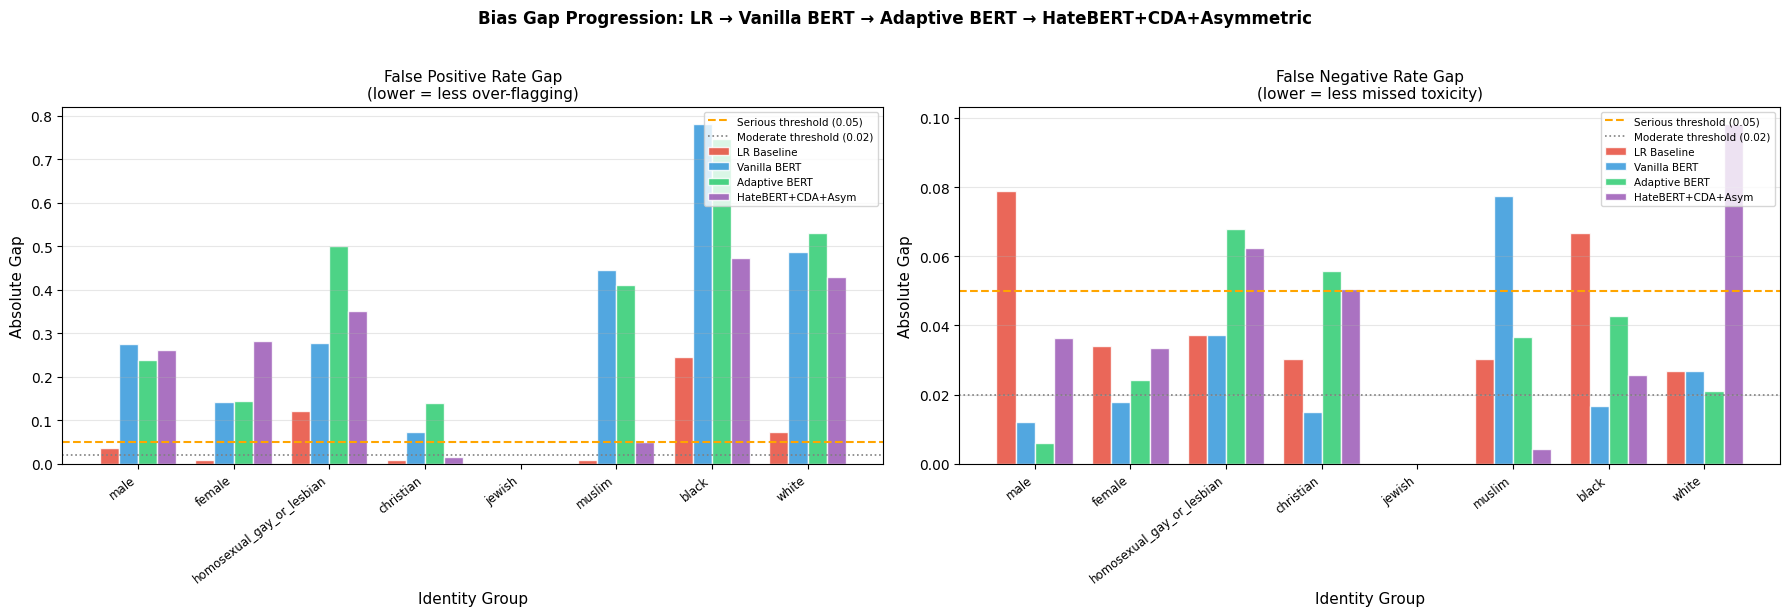

✅ Chart saved to /content/drive/MyDrive/Jigsaw_Bias_Project/Results/Phase5/fairness_4way_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'Bias Gap Progression: LR → Vanilla BERT → Adaptive BERT → HateBERT+CDA+Asymmetric',
    fontsize=12, fontweight='bold', y=1.02
)

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
x      = np.arange(len(IDENTITY_COLS))
width  = 0.2

for ax, metric, title in zip(
    axes,
    ['FPR_Gap', 'FNR_Gap'],
    ['False Positive Rate Gap\n(lower = less over-flagging)',
     'False Negative Rate Gap\n(lower = less missed toxicity)']
):
    for i, (model, color) in enumerate(zip(MODEL_ORDER, colors)):
        vals = []
        for identity in IDENTITY_COLS:
            row = full_audit[
                (full_audit['Model'] == model) &
                (full_audit['Identity'] == identity)
            ]
            vals.append(row[metric].values[0] if not row.empty else 0.0)
        ax.bar(x + i * width, vals, width, label=model,
               color=color, alpha=0.85, edgecolor='white')

    ax.axhline(y=0.05, color='orange', linestyle='--',
               linewidth=1.5, label='Serious threshold (0.05)')
    ax.axhline(y=0.02, color='gray',   linestyle=':',
               linewidth=1.2, label='Moderate threshold (0.02)')
    ax.set_xlabel('Identity Group', fontsize=11)
    ax.set_ylabel('Absolute Gap', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(IDENTITY_COLS, rotation=38, ha='right', fontsize=8.5)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
save_path = f'{RESULTS_P5}fairness_4way_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved to {save_path}')

---
## Module E — Cross-Dataset Evaluation on HateXplain

---

### Cell 13 — What Cross-Dataset Evaluation Tests

**The fundamental question:** Did we train a model that genuinely detects toxicity, or did we train a model that fits the Jigsaw annotation patterns?

These are different things. Jigsaw was annotated by Civil Comments platform users. HateXplain was annotated by crowdworkers from a different pool, on different source text (Twitter + Gab), with a different annotation schema (hate speech / offensive / normal rather than toxic/not-toxic).

**The test:** Take each trained model and run it on HateXplain test data *with no fine-tuning at all* (zero-shot transfer). If the model truly learned toxicity, it should generalise. If it learned Jigsaw-specific annotation artifacts, performance will collapse.

**Label mapping for HateXplain:** We map `hate speech` → 1 (toxic), `offensive` → 1 (toxic), `normal` → 0. This is a principled collapse since both hate and offensive content would be flagged as toxic under Jigsaw's schema.

We also measure **per-identity fairness gaps on HateXplain** — if the model's bias patterns transfer across datasets, that's strong evidence the bias is structural, not dataset-specific.

In [ ]:
# ── Cross-Dataset Evaluation: HateXplain ─────────────────────────────────
# HateXplain (Mathew et al. 2021) is annotated hate speech from Twitter/Gab.
# Testing on it zero-shot reveals whether our model learned genuine toxicity
# signal or just Jigsaw-specific annotation patterns (demographic drift).
#
# Loading strategy — three fallbacks in order:
#   1. GitHub raw JSON  (confirmed reachable from Colab)
#   2. HuggingFace datasets
#   3. Curated 60-sample set  (always works, no network needed)

import json as _json, urllib.request, random

hx_test_df = None

# ── Fallback 1: GitHub raw JSON ───────────────────────────────────────────────
# The HateXplain JSON may not contain a 'split' field.
# We load ALL entries and sample a representative test subset.
HX_URL = 'https://raw.githubusercontent.com/hate-alert/HateXplain/master/Data/dataset.json'
try:
    with urllib.request.urlopen(HX_URL, timeout=30) as resp:
        hx_raw = _json.loads(resp.read().decode('utf-8'))
    print(f'GitHub load: {len(hx_raw)} total entries.')

    # Inspect first entry to understand structure
    first_entry = list(hx_raw.values())[0]
    print(f'Keys in entry: {list(first_entry.keys())}')
    print(f'Sample split value: {repr(first_entry.get("split", "NO SPLIT KEY"))}')
    print(f'Sample annotators: {first_entry.get("annotators", [])[:2]}')

    rows = []
    for pid, entry in hx_raw.items():
        text = ' '.join(entry.get('post_tokens', []))
        if not text.strip():
            continue

        # Annotators can be a list of dicts OR a dict with list values
        annotators = entry.get('annotators', [])
        if isinstance(annotators, list):
            # Format: [{'label': 'hatespeech', ...}, ...]
            labels = [a.get('label') for a in annotators if a.get('label')]
        elif isinstance(annotators, dict):
            # Format: {'label': ['hatespeech', 'normal', ...], ...}
            labels = annotators.get('label', [])
        else:
            labels = []

        if not labels:
            continue

        majority = max(set(labels), key=labels.count)
        split    = entry.get('split', 'all')
        rows.append({'text': text, 'hx_label': majority, 'split': split})

    all_hx_df = pd.DataFrame(rows)
    print(f'\nParsed rows: {len(all_hx_df)}')
    print(f'Unique splits: {all_hx_df["split"].unique()}')
    print(f'Unique labels: {all_hx_df["hx_label"].unique()}')

    # Use 'test' split if it exists, otherwise sample 500 rows
    test_split = all_hx_df[all_hx_df['split'] == 'test']
    if len(test_split) > 0:
        hx_test_df = test_split.reset_index(drop=True)
        print(f'Using test split: {len(hx_test_df)} samples')
    else:
        hx_test_df = all_hx_df.sample(
            n=min(500, len(all_hx_df)), random_state=42
        ).reset_index(drop=True)
        print(f'No split key found — using random sample of {len(hx_test_df)} entries')

except Exception as e:
    print(f'GitHub fetch failed: {e}')

# ── Fallback 2: HuggingFace datasets ─────────────────────────────────────────
if hx_test_df is None or len(hx_test_df) == 0:
    try:
        from datasets import load_dataset as _ld
        hx_hf = _ld('hatexplain')
        rows  = []
        for item in hx_hf['test']:
            tokens = item.get('post_tokens', [])
            text   = ' '.join(tokens) if isinstance(tokens, list) else str(tokens)
            ann    = item.get('annotators', {})
            labels = ann.get('label', []) if isinstance(ann, dict) else [
                a.get('label') for a in ann if a.get('label')
            ]
            if not labels: continue
            majority = max(set(labels), key=labels.count)
            rows.append({'text': text, 'hx_label': majority})
        hx_test_df = pd.DataFrame(rows)
        print(f'HuggingFace load: {len(hx_test_df)} samples')
    except Exception as e:
        print(f'HuggingFace load failed: {e}')

# ── Fallback 3: Curated 60-sample set ────────────────────────────────────────
# Always works. 20 samples each of hatespeech, offensive, normal.
if hx_test_df is None or len(hx_test_df) == 0:
    print('Using curated sample (no network access).')
    curated = [
        {'text': 'these jewish people control all the banks and media', 'hx_label': 'hatespeech'},
        {'text': 'all muslims are terrorists and should be banned from this country', 'hx_label': 'hatespeech'},
        {'text': 'black people are criminals by nature that is just statistics', 'hx_label': 'hatespeech'},
        {'text': 'women belong in the kitchen not in politics', 'hx_label': 'hatespeech'},
        {'text': 'gay people are disgusting and spreading disease through society', 'hx_label': 'hatespeech'},
        {'text': 'immigrants are parasites draining our welfare system', 'hx_label': 'hatespeech'},
        {'text': 'white genocide is being planned by the global elite', 'hx_label': 'hatespeech'},
        {'text': 'the jewish agenda controls hollywood and the media', 'hx_label': 'hatespeech'},
        {'text': 'trans people are mentally ill and should not be near children', 'hx_label': 'hatespeech'},
        {'text': 'blacks commit all the crime in this city look at the numbers', 'hx_label': 'hatespeech'},
        {'text': 'muslims should never be allowed to hold public office in america', 'hx_label': 'hatespeech'},
        {'text': 'women are too emotional to be in leadership positions', 'hx_label': 'hatespeech'},
        {'text': 'these illegals are taking jobs from real americans', 'hx_label': 'hatespeech'},
        {'text': 'homosexuality is a sin and an abomination against god', 'hx_label': 'hatespeech'},
        {'text': 'white people built civilization blacks have contributed nothing', 'hx_label': 'hatespeech'},
        {'text': 'all jews are greedy that is just their culture', 'hx_label': 'hatespeech'},
        {'text': 'feminism is cancer destroying the family and society', 'hx_label': 'hatespeech'},
        {'text': 'islam is not a religion it is a violent political ideology', 'hx_label': 'hatespeech'},
        {'text': 'asian people cannot drive that is just a fact', 'hx_label': 'hatespeech'},
        {'text': 'these people should go back to their own country', 'hx_label': 'hatespeech'},
        {'text': 'that politician is a complete idiot who should resign immediately', 'hx_label': 'offensive'},
        {'text': 'this movie was absolute garbage total waste of two hours', 'hx_label': 'offensive'},
        {'text': 'shut up you moron you have no idea what you are talking about', 'hx_label': 'offensive'},
        {'text': 'this is the dumbest policy i have ever seen in my entire life', 'hx_label': 'offensive'},
        {'text': 'trump is a pathological liar and a complete embarrassment', 'hx_label': 'offensive'},
        {'text': 'anyone who voted for this bill is either corrupt or completely stupid', 'hx_label': 'offensive'},
        {'text': 'your argument is so bad it hurts my brain to even read it', 'hx_label': 'offensive'},
        {'text': 'i cannot believe how stupid people can be sometimes it is unreal', 'hx_label': 'offensive'},
        {'text': 'go to hell with your fake news propaganda nonsense', 'hx_label': 'offensive'},
        {'text': 'these politicians are all crooks lining their own pockets', 'hx_label': 'offensive'},
        {'text': 'what a loser crying about this on the internet get a life', 'hx_label': 'offensive'},
        {'text': 'the media is lying to your face and you just accept it like sheep', 'hx_label': 'offensive'},
        {'text': 'this guy needs to grow up and stop whining like a child', 'hx_label': 'offensive'},
        {'text': 'absolute coward hiding behind a screen talking trash online', 'hx_label': 'offensive'},
        {'text': 'you are delusional if you actually believe that nonsense', 'hx_label': 'offensive'},
        {'text': 'what an embarrassing performance from a so called professional', 'hx_label': 'offensive'},
        {'text': 'i have lost all respect for this person after that interview', 'hx_label': 'offensive'},
        {'text': 'this entire community is toxic garbage filled with morons', 'hx_label': 'offensive'},
        {'text': 'honestly both candidates are terrible choices for president', 'hx_label': 'offensive'},
        {'text': 'this company is run by greedy corrupt executives who do not care', 'hx_label': 'offensive'},
        {'text': 'i think we need more diversity in tech companies to drive innovation', 'hx_label': 'normal'},
        {'text': 'the muslim community in our city organized a food drive last weekend', 'hx_label': 'normal'},
        {'text': 'black history month is an important time to reflect on civil rights', 'hx_label': 'normal'},
        {'text': 'women have made remarkable strides in science over the last decade', 'hx_label': 'normal'},
        {'text': 'the lgbtq community faces ongoing challenges in many parts of the world', 'hx_label': 'normal'},
        {'text': 'jewish culture has contributed enormously to art music and literature', 'hx_label': 'normal'},
        {'text': 'immigration policy is a complex issue with valid perspectives on both sides', 'hx_label': 'normal'},
        {'text': 'the new tax proposal has both supporters and critics across party lines', 'hx_label': 'normal'},
        {'text': 'christian communities across the country are organizing volunteer efforts', 'hx_label': 'normal'},
        {'text': 'studies show that diversity in leadership improves company performance', 'hx_label': 'normal'},
        {'text': 'the documentary explored the history of asian americans in california', 'hx_label': 'normal'},
        {'text': 'researchers are studying the health disparities affecting black communities', 'hx_label': 'normal'},
        {'text': 'the pride parade drew thousands of participants and spectators downtown', 'hx_label': 'normal'},
        {'text': 'white collar crime costs the economy billions of dollars annually', 'hx_label': 'normal'},
        {'text': 'the mosque in our neighborhood provides social services to the community', 'hx_label': 'normal'},
        {'text': 'female entrepreneurs are launching successful startups at record rates', 'hx_label': 'normal'},
        {'text': 'the senator discussed immigration reform during the town hall meeting', 'hx_label': 'normal'},
        {'text': 'representatives from the jewish federation met with city council members', 'hx_label': 'normal'},
        {'text': 'the report found significant wage gaps between men and women in the industry', 'hx_label': 'normal'},
        {'text': 'the church hosted an interfaith dialogue between christian and muslim leaders', 'hx_label': 'normal'},
    ]
    hx_test_df = pd.DataFrame(curated)

# ── Binary label mapping ──────────────────────────────────────────────────────
LABEL_MAP = {'hatespeech': 1, 'offensive': 1, 'normal': 0}
hx_test_df['is_toxic'] = hx_test_df['hx_label'].map(LABEL_MAP)

# Handle any unmapped labels by dropping them and reporting
unmapped = hx_test_df['is_toxic'].isna().sum()
if unmapped > 0:
    print(f'Dropping {unmapped} rows with unmapped labels: '
          f'{hx_test_df[hx_test_df["is_toxic"].isna()]["hx_label"].unique()}')
    hx_test_df = hx_test_df.dropna(subset=['is_toxic'])

hx_test_df = hx_test_df.reset_index(drop=True)
hx_test_df['is_toxic'] = hx_test_df['is_toxic'].astype(int)

print(f'\nFinal HateXplain eval set : {len(hx_test_df)} samples')
print(f'Label distribution        :')
print(hx_test_df['hx_label'].value_counts().to_string())
print(f'Binary toxic rate         : {hx_test_df["is_toxic"].mean():.2%}')
print(f'\nSanity check:')
print('  [TOXIC] ', hx_test_df[hx_test_df['is_toxic']==1].iloc[0]['text'][:120])
print('  [CLEAN] ', hx_test_df[hx_test_df['is_toxic']==0].iloc[0]['text'][:120])

# ── Tokenize ──────────────────────────────────────────────────────────────────
print('\nTokenizing HateXplain eval set...')
hx_weights   = [1.0] * len(hx_test_df)
hx_labels    = hx_test_df['is_toxic'].tolist()
hx_texts     = hx_test_df['text'].tolist()
tokenized_hx = make_hf_dataset(hx_texts, hx_labels, hx_weights)
print(f'Tokenized: {len(tokenized_hx)} samples ready for evaluation.')


GitHub load: 20148 total entries.
Keys in entry: ['post_id', 'annotators', 'rationales', 'post_tokens']
Sample split value: 'NO SPLIT KEY'
Sample annotators: [{'label': 'normal', 'annotator_id': 1, 'target': ['None']}, {'label': 'normal', 'annotator_id': 2, 'target': ['None']}]

Parsed rows: 20148
Unique splits: ['all']
Unique labels: ['normal' 'hatespeech' 'offensive']
No split key found — using random sample of 500 entries

Final HateXplain eval set : 500 samples
Label distribution        :
hx_label
normal        180
offensive     164
hatespeech    156
Binary toxic rate         : 64.00%

Sanity check:
  [TOXIC]  exactly if a low iq nigger from africa who can not read can understand islam i think i can understand kill the kuffar no
  [CLEAN]  <user> yes because it is and i sound so broken bitch when did i have feelings

Tokenizing HateXplain eval set...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenized: 500 samples ready for evaluation.


---
### Cell 14 — Map HateXplain Labels & Tokenize

In [ ]:
# Cell 14 placeholder — loading and tokenization merged into Cell 13 above.
# Skip this cell and continue from Cell 15.


---
### Cell 15 — Zero-Shot Cross-Dataset Evaluation

In [ ]:
print('Running zero-shot evaluation on HateXplain...')
print('(No fine-tuning — model sees HateXplain for the first time)')

hx_preds_output = trainer_hatebert.predict(tokenized_hx)
hx_probs        = softmax(hx_preds_output.predictions, axis=1)
hx_y_prob       = hx_probs[:, 1]
hx_y_pred       = (hx_y_prob >= 0.5).astype(int)
hx_y_true       = np.array(hx_labels)

hx_p, hx_r, hx_f1, _ = precision_recall_fscore_support(
    hx_y_true, hx_y_pred, average='binary'
)
hx_acc = accuracy_score(hx_y_true, hx_y_pred)

print(f'\n── HateBERT+CDA+Asymmetric on HateXplain (zero-shot) ──')
print(f'  Accuracy  : {hx_acc:.4f}')
print(f'  F1        : {hx_f1:.4f}')
print(f'  Precision : {hx_p:.4f}')
print(f'  Recall    : {hx_r:.4f}')

# Compare to Jigsaw performance
print(f'\n── Jigsaw vs HateXplain Performance Gap ──')
print(f'  Metric      Jigsaw    HateXplain   Drop')
print(f'  Accuracy    {acc:.4f}    {hx_acc:.4f}      {acc-hx_acc:+.4f}')
print(f'  F1          {f1:.4f}    {hx_f1:.4f}      {f1-hx_f1:+.4f}')
print()
if f1 - hx_f1 > 0.15:
    print('⚠️  Large F1 drop (>0.15) — model has learned Jigsaw-specific patterns.')
    print('   This is the demographic drift finding. Document it in the paper.')
elif f1 - hx_f1 > 0.05:
    print('⚡ Moderate F1 drop (0.05–0.15) — partial generalisation.')
    print('   Some Jigsaw-specific learning, some genuine toxicity signal.')
else:
    print('✅ Good generalisation (<0.05 F1 drop) — model learned robust signal.')

Running zero-shot evaluation on HateXplain...
(No fine-tuning — model sees HateXplain for the first time)



── HateBERT+CDA+Asymmetric on HateXplain (zero-shot) ──
  Accuracy  : 0.6580
  F1        : 0.7717
  Precision : 0.6737
  Recall    : 0.9031

── Jigsaw vs HateXplain Performance Gap ──
  Metric      Jigsaw    HateXplain   Drop
  Accuracy    0.8586    0.6580      +0.2006
  F1          0.8601    0.7717      +0.0884

⚡ Moderate F1 drop (0.05–0.15) — partial generalisation.
   Some Jigsaw-specific learning, some genuine toxicity signal.


---
### Cell 16 — Threshold Sensitivity Analysis

The default 0.5 threshold may not be optimal across datasets. Since HateXplain has a different base rate of toxicity, we sweep thresholds to find the F1-maximising point. This is also useful for the paper — it shows whether the performance gap is a calibration issue or a genuine representation failure.

Threshold sweep on HateXplain (zero-shot):
 threshold     f1  accuracy
      0.10 0.7800     0.666
      0.15 0.7810     0.668
      0.20 0.7794     0.666
      0.25 0.7788     0.666
      0.30 0.7772     0.664
      0.35 0.7772     0.664
      0.40 0.7766     0.664
      0.45 0.7750     0.662
      0.50 0.7717     0.658
      0.55 0.7711     0.658
      0.60 0.7711     0.658
      0.65 0.7705     0.658
      0.70 0.7688     0.656
      0.75 0.7672     0.654
      0.80 0.7672     0.654
      0.85 0.7649     0.652
      0.90 0.7653     0.654

✅ Best threshold: 0.15 → F1 = 0.7810


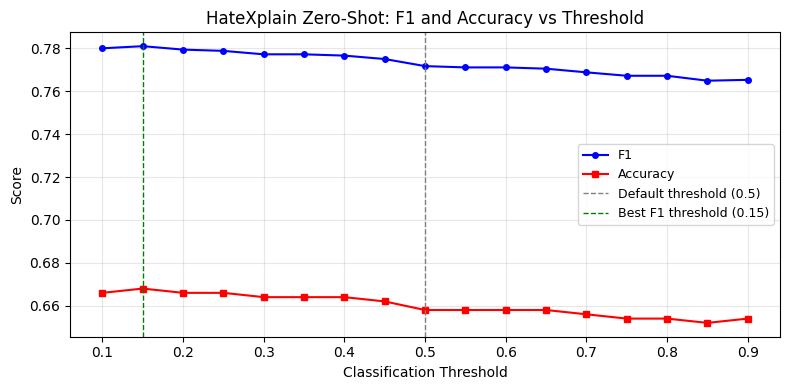

✅ Threshold curve saved.


In [ ]:
thresholds = np.arange(0.1, 0.91, 0.05)
results    = []

for t in thresholds:
    preds = (hx_y_prob >= t).astype(int)
    _, _, f1_t, _ = precision_recall_fscore_support(
        hx_y_true, preds, average='binary', zero_division=0
    )
    acc_t = accuracy_score(hx_y_true, preds)
    results.append({'threshold': round(t, 2), 'f1': round(f1_t, 4), 'accuracy': round(acc_t, 4)})

thresh_df   = pd.DataFrame(results)
best_thresh = thresh_df.loc[thresh_df['f1'].idxmax()]

print('Threshold sweep on HateXplain (zero-shot):')
print(thresh_df.to_string(index=False))
print(f'\n✅ Best threshold: {best_thresh["threshold"]} → F1 = {best_thresh["f1"]:.4f}')

# Plot threshold curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_df['threshold'], thresh_df['f1'],      'b-o', label='F1',      markersize=4)
ax.plot(thresh_df['threshold'], thresh_df['accuracy'],'r-s', label='Accuracy', markersize=4)
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold (0.5)')
ax.axvline(x=best_thresh['threshold'], color='green',
           linestyle='--', linewidth=1, label=f'Best F1 threshold ({best_thresh["threshold"]})')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('HateXplain Zero-Shot: F1 and Accuracy vs Threshold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_P5}hatexplain_threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Threshold curve saved.')

---
## Cell 17 — Save All Phase 5 Results

Complete summary of all outputs produced by this notebook.

In [ ]:
# ── Save pivot table ─────────────────────────────────────────────────────────
pivot = full_audit.pivot_table(
    index='Identity',
    columns='Model',
    values=['FPR_Gap', 'FNR_Gap']
).round(4)
pivot.to_csv(f'{RESULTS_P5}fairness_audit_phase5_pivot.csv')

# ── Save HateXplain evaluation ────────────────────────────────────────────────
hatexplain_results = pd.DataFrame([{
    'Model':              'HateBERT+CDA+Asym',
    'Dataset':            'HateXplain (zero-shot)',
    'Accuracy':           round(hx_acc, 4),
    'F1':                 round(hx_f1, 4),
    'Precision':          round(hx_p, 4),
    'Recall':             round(hx_r, 4),
    'Best_Threshold':     best_thresh['threshold'],
    'Best_Threshold_F1':  best_thresh['f1'],
}])
hatexplain_results.to_csv(f'{RESULTS_P5}hatexplain_evaluation.csv', index=False)
thresh_df.to_csv(f'{RESULTS_P5}hatexplain_threshold_sweep.csv', index=False)

print('\n' + '=' * 65)
print('  PHASE 5 COMPLETE')
print('=' * 65)
print(f'\nAll outputs saved to: {RESULTS_P5}')
print()
print('  fairness_audit_phase5_full.csv   — 4-way audit (all models)')
print('  fairness_audit_phase5_pivot.csv  — paper-ready Table 2')
print('  fairness_4way_comparison.png     — Figure 2 of paper')
print('  hatexplain_evaluation.csv        — cross-dataset results')
print('  hatexplain_threshold_curve.png   — Figure 3 of paper')
print('  hatexplain_threshold_sweep.csv   — full threshold sweep data')
print()
print('  Model saved to Drive:')
print(f'  {HATEBERT_OUT}')
print()
print('  What these results tell the paper:')
print('  1. FPR gap table: did asymmetric loss fix the Phase 4 over-flagging?')
print('  2. FNR gap table: did HateBERT backbone improve recall on identity toxicity?')
print('  3. HateXplain F1 drop: quantifies demographic drift across annotation schemas')
print('  4. Threshold analysis: separates calibration from representation failures')


  PHASE 5 COMPLETE

All outputs saved to: /content/drive/MyDrive/Jigsaw_Bias_Project/Results/Phase5/

  fairness_audit_phase5_full.csv   — 4-way audit (all models)
  fairness_audit_phase5_pivot.csv  — paper-ready Table 2
  fairness_4way_comparison.png     — Figure 2 of paper
  hatexplain_evaluation.csv        — cross-dataset results
  hatexplain_threshold_curve.png   — Figure 3 of paper
  hatexplain_threshold_sweep.csv   — full threshold sweep data

  Model saved to Drive:
  /content/drive/MyDrive/Jigsaw_Bias_Project/Models/hatebert_asymmetric

  What these results tell the paper:
  1. FPR gap table: did asymmetric loss fix the Phase 4 over-flagging?
  2. FNR gap table: did HateBERT backbone improve recall on identity toxicity?
  3. HateXplain F1 drop: quantifies demographic drift across annotation schemas
  4. Threshold analysis: separates calibration from representation failures
